<a href="https://colab.research.google.com/github/huangste/bbo-challenge/blob/main/BBO_stage2_exploration_week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import re
import pandas as pd
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel, WhiteKernel
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor

In [2]:
#!unzip /content/Initial_data_points_starter.zip

In [3]:
from google.colab import drive
import os
import numpy as np
import re

# Mount Google Drive
drive.mount('/content/drive')

# Define your persistent base directory
BASE_DIR = '/content/drive/MyDrive/BBO_Challenge'
os.makedirs(BASE_DIR, exist_ok=True)
BASE_PATH = '/content/initial_data'
ZIP_PATH = f"{BASE_DIR}/Initial_data_points_starter.zip"
EXTRACT_DIR = f"{BASE_DIR}/initial_data"
INPUTS_TXT = f"{BASE_DIR}/inputs.txt"
OUTPUTS_TXT = f"{BASE_DIR}/outputs.txt"

if not os.path.exists(EXTRACT_DIR):
    print("Extracting initial data to Google Drive...")
    !unzip -q {ZIP_PATH} -d {BASE_DIR}

Mounted at /content/drive


In [4]:
with open(OUTPUTS_TXT,'r') as f:
    print(f.read())

[np.float64(-4.427398523461322e-21), np.float64(-0.001295902257253424), np.float64(-0.18198498150273396), np.float64(-1.1360324509695903), np.float64(1712.518504884033), np.float64(-0.4047465653372001), np.float64(0.9347813911705228), np.float64(9.808023642848)]
[np.float64(9.758641896745353e-97), np.float64(0.5422372443859094), np.float64(-0.18163448168163152), np.float64(0.3684431473055416), np.float64(6065.458032849537), np.float64(-0.5686713750565812), np.float64(1.8666937525658636), np.float64(9.7853964049635)]


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



# -----------------------------
# Loader
# -----------------------------
def load_function_data(i):

    X = np.load(f'{EXTRACT_DIR}/function_{i}/initial_inputs.npy')
    Y = np.load(f'{EXTRACT_DIR}/function_{i}/initial_outputs.npy')

    return X, Y

def load_new_round_data(
    input_path=INPUTS_TXT,
    output_path=OUTPUTS_TXT
):
    new_X = {}
    new_Y = {}

    # ----- INPUTS -----
    with open(input_path, 'r') as f:
        txt_x = f.read()

    arrays = re.findall(r'array\(\[(.*?)\]\)', txt_x)

    for i, arr_str in enumerate(arrays, start=1):
        x = np.array([float(v.strip()) for v in arr_str.split(',')])
        new_X[i] = x

    # ----- OUTPUTS -----
    with open(output_path, 'r') as f:
        txt_y = f.read()

    # Extract values inside np.float64(...)
    y_values = re.findall(r'np\.float64\((.*?)\)', txt_y)

    for i, y_str in enumerate(y_values, start=1):
        new_Y[i] = float(y_str)

    return new_X, new_Y


def load_updated_function_data(i):

    X, Y = load_function_data(i)

    new_X, new_Y = load_new_round_data()

    n_rounds = len(new_Y) // 8

    for r in range(n_rounds):

        idx = r*8 + i

        X = np.vstack([X, new_X[idx].reshape(1,-1)])
        Y = np.append(Y, new_Y[idx])

    return X, Y




# -----------------------------
# Summary statistics
# -----------------------------
def summarize_function(i):

    X, Y = load_updated_function_data(i)

    print(f'\nFUNCTION {i}')
    print('-' * 40)

    print('Input shape :', X.shape)
    print('Output shape:', Y.shape)

    print('\nY statistics')
    print('Best Y :', np.max(Y))
    print('Mean Y :', np.mean(Y))
    print('Std Y  :', np.std(Y))
    print('Min Y  :', np.min(Y))

    best_idx = np.argmax(Y)

    print('\nBest observed X:')
    print(X[best_idx])



# -----------------------------
# Run summaries for all 8
# -----------------------------
for i in range(1, 9):

    summarize_function(i)


FUNCTION 1
----------------------------------------
Input shape : (12, 2)
Output shape: (12,)

Y statistics
Best Y : 7.710875114502849e-16
Mean Y : -0.0003005052203635588
Std Y  : 0.000996663063489224
Min Y  : -0.0036060626443634764

Best observed X:
[0.73102363 0.73299988]

FUNCTION 2
----------------------------------------
Input shape : (12, 2)
Output shape: (12,)

Y statistics
Best Y : 0.6112052157614438
Mean Y : 0.23730658377733993
Std Y  : 0.23420884411737505
Min Y  : -0.06562362443733738

Best observed X:
[0.70263656 0.9265642 ]

FUNCTION 3
----------------------------------------
Input shape : (17, 3)
Output shape: (17,)

Y statistics
Best Y : -0.034835313350078584
Mean Y : -0.11594847553565779
Std Y  : 0.08268015751852571
Min Y  : -0.3989255131463011

Best observed X:
[0.49258141 0.61159319 0.34017639]

FUNCTION 4
----------------------------------------
Input shape : (32, 4)
Output shape: (32,)

Y statistics
Best Y : 0.3684431473055416
Mean Y : -16.185162807570755
Std Y  : 7

In [6]:
new_X, new_Y = load_new_round_data()

print(len(new_Y))

for k,v in new_Y.items():
    print(k, v)

16
1 -4.427398523461322e-21
2 -0.001295902257253424
3 -0.18198498150273396
4 -1.1360324509695903
5 1712.518504884033
6 -0.4047465653372001
7 0.9347813911705228
8 9.808023642848
9 9.758641896745353e-97
10 0.5422372443859094
11 -0.18163448168163152
12 0.3684431473055416
13 6065.458032849537
14 -0.5686713750565812
15 1.8666937525658636
16 9.7853964049635


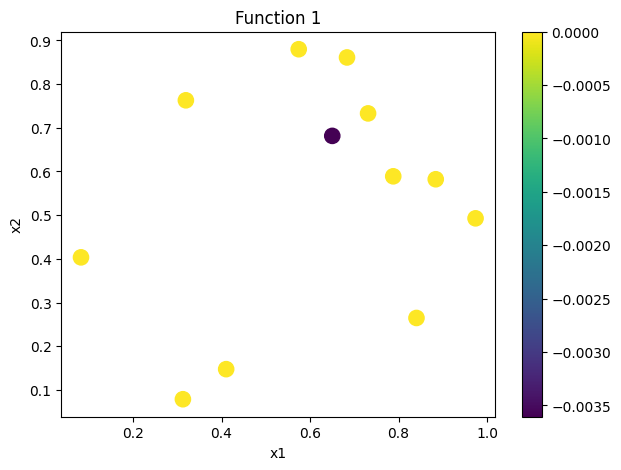

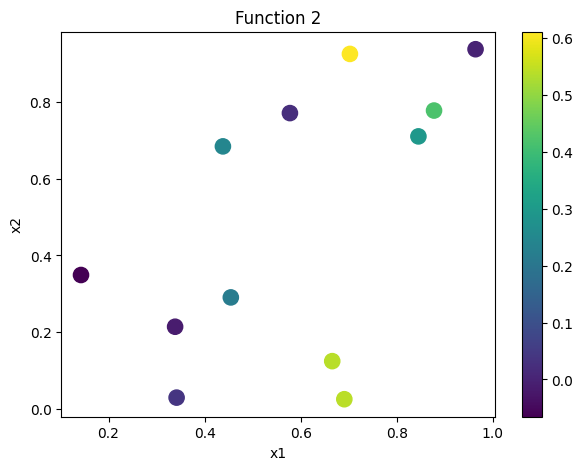

In [7]:
def plot_2d_function(i):

    X, Y = load_updated_function_data(i)

    plt.figure(figsize=(7,5))

    scatter = plt.scatter(
        X[:,0],
        X[:,1],
        c=Y,
        s=120
    )

    plt.colorbar(scatter)

    plt.xlabel('x1')
    plt.ylabel('x2')

    plt.title(f'Function {i}')

    plt.show()


plot_2d_function(1)
plot_2d_function(2)

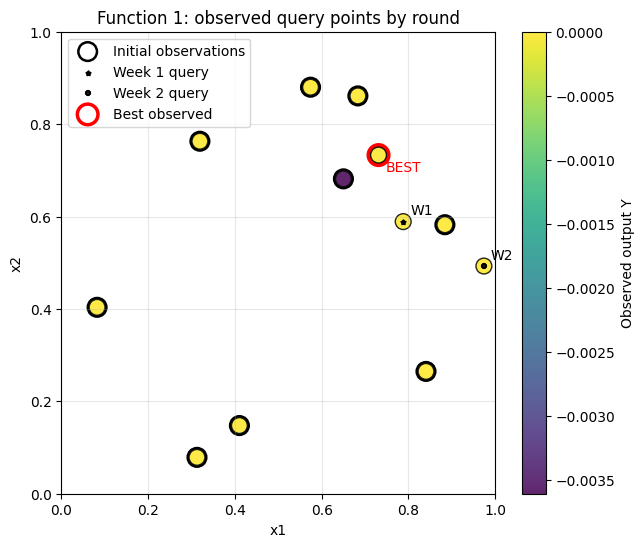

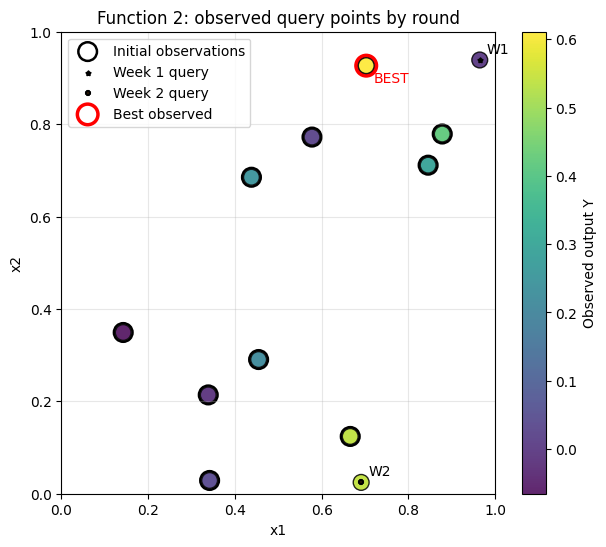

In [8]:
def plot_2d_observations_with_rounds(i):
    X, Y = load_updated_function_data(i)

    n_initial = X.shape[0] - 2  # since we now have Week 1 + Week 2 appended

    best_idx = np.argmax(Y)

    plt.figure(figsize=(7, 6))

    # All points coloured by Y
    scatter = plt.scatter(
        X[:, 0], X[:, 1],
        c=Y,
        s=130,
        alpha=0.85,
        edgecolor="black"
    )

    plt.colorbar(scatter, label="Observed output Y")

    # Initial points
    plt.scatter(
        X[:n_initial, 0], X[:n_initial, 1],
        facecolors="none",
        edgecolors="black",
        s=180,
        linewidths=1.8,
        label="Initial observations"
    )

    # Week 1 point
    plt.scatter(
        X[n_initial, 0], X[n_initial, 1],
        marker="*",
        s=10,
        edgecolor="black",
        linewidth=1.5,
        label="Week 1 query",
        zorder=5
    )

    plt.annotate(
        "W1",
        (X[n_initial, 0], X[n_initial, 1]),
        xytext=(5, 5),
        textcoords="offset points"
    )

    # Week 2 point
    plt.scatter(
        X[n_initial + 1, 0], X[n_initial + 1, 1],
        marker="P",
        s=10,
        edgecolor="black",
        linewidth=1.5,
        label="Week 2 query",
        zorder=5
    )

    plt.annotate(
        "W2",
        (X[n_initial + 1, 0], X[n_initial + 1, 1]),
        xytext=(5, 5),
        textcoords="offset points"
    )

    # Best point
    plt.scatter(
        X[best_idx, 0], X[best_idx, 1],
        facecolors="none",
        edgecolors="red",
        s=220,
        linewidth=2.5,
        label="Best observed",
        zorder=6
    )

    plt.annotate(
        "BEST",
        (X[best_idx, 0], X[best_idx, 1]),
        xytext=(5, -12),
        textcoords="offset points",
        color="red"
    )

    plt.title(f"Function {i}: observed query points by round")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.legend(loc="best")
    plt.grid(alpha=0.3)
    plt.show()


plot_2d_observations_with_rounds(1)
plot_2d_observations_with_rounds(2)

In [9]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel
import numpy as np
import matplotlib.pyplot as plt
# produce a 2D contour slice for function 3-8
def plot_gp_2d_slice(i, dims=(0, 1), nu=2.5, grid_size=60):
    X, Y = load_updated_function_data(i)
    d = X.shape[1]

    best_idx = np.argmax(Y)
    x_base = X[best_idx].copy()

    kernel = (
        ConstantKernel(1.0, (1e-3, 1e3))
        * Matern(length_scale=[0.3]*d, length_scale_bounds=(1e-2, 1e1), nu=nu)
        + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-2))
    )

    gp = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=42
    )

    gp.fit(X, Y)

    a, b = dims
    grid_a = np.linspace(0, 1, grid_size)
    grid_b = np.linspace(0, 1, grid_size)

    AA, BB = np.meshgrid(grid_a, grid_b)

    X_grid = np.tile(x_base, (grid_size * grid_size, 1))
    X_grid[:, a] = AA.ravel()
    X_grid[:, b] = BB.ravel()

    mu, sigma = gp.predict(X_grid, return_std=True)

    MU = mu.reshape(grid_size, grid_size)
    SIGMA = sigma.reshape(grid_size, grid_size)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    c1 = axes[0].contourf(AA, BB, MU, levels=30)
    axes[0].scatter(X[:, a], X[:, b], c=Y, edgecolor="black", s=60)
    axes[0].scatter(x_base[a], x_base[b], marker="X", s=180, edgecolor="black")
    axes[0].set_title(f"Function {i}: GP posterior mean slice")
    axes[0].set_xlabel(f"x{a+1}")
    axes[0].set_ylabel(f"x{b+1}")
    fig.colorbar(c1, ax=axes[0])

    c2 = axes[1].contourf(AA, BB, SIGMA, levels=30)
    axes[1].scatter(X[:, a], X[:, b], c=Y, edgecolor="black", s=60)
    axes[1].scatter(x_base[a], x_base[b], marker="X", s=180, edgecolor="black")
    axes[1].set_title(f"Function {i}: GP posterior uncertainty slice")
    axes[1].set_xlabel(f"x{a+1}")
    axes[1].set_ylabel(f"x{b+1}")
    fig.colorbar(c2, ax=axes[1])

    plt.tight_layout()
    plt.show()

    print("Best X used as slice centre:")
    print(x_base)
    print("Fitted kernel:")
    print(gp.kernel_)

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


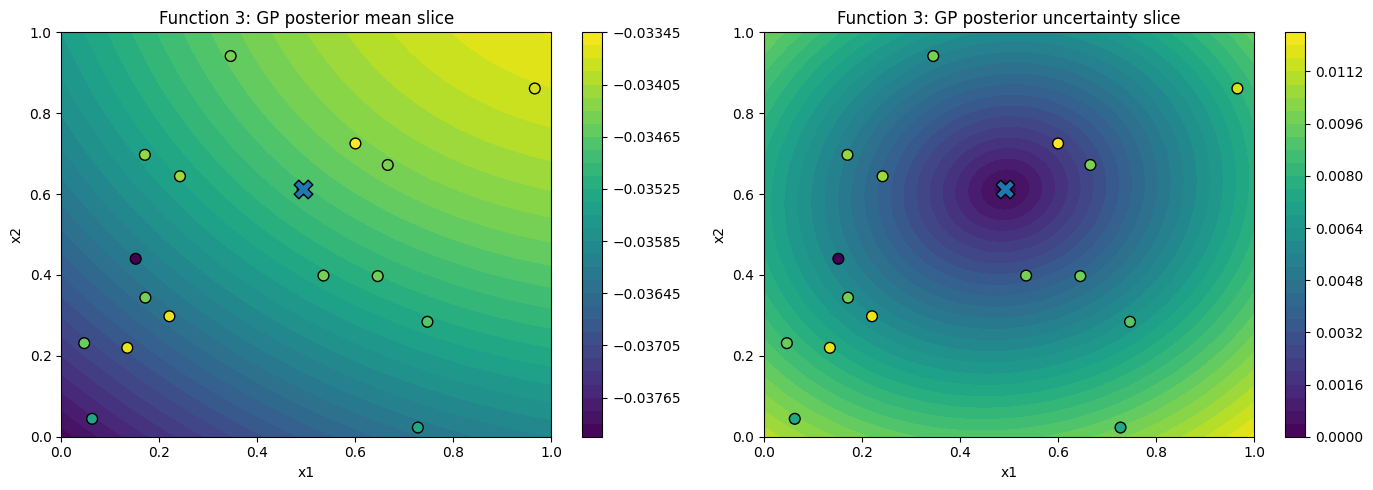

Best X used as slice centre:
[0.49258141 0.61159319 0.34017639]
Fitted kernel:
1.12**2 * Matern(length_scale=[10, 10, 0.0342], nu=1.5) + WhiteKernel(noise_level=1e-06)


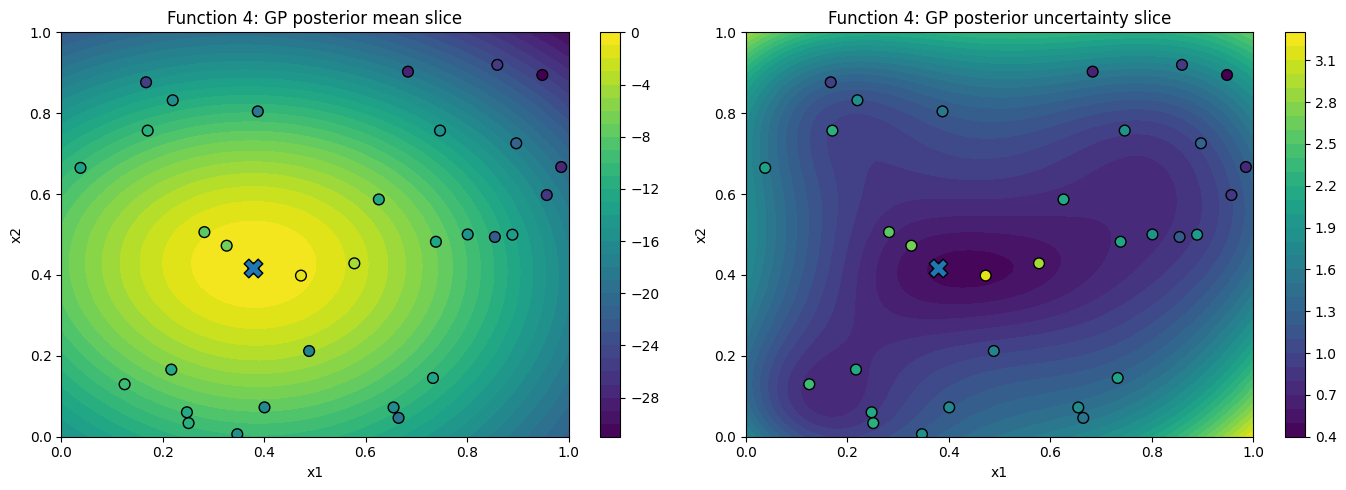

Best X used as slice centre:
[0.378762 0.416286 0.401546 0.396799]
Fitted kernel:
2.95**2 * Matern(length_scale=[1.59, 1.39, 1.47, 1.45], nu=2.5) + WhiteKernel(noise_level=0.0021)


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


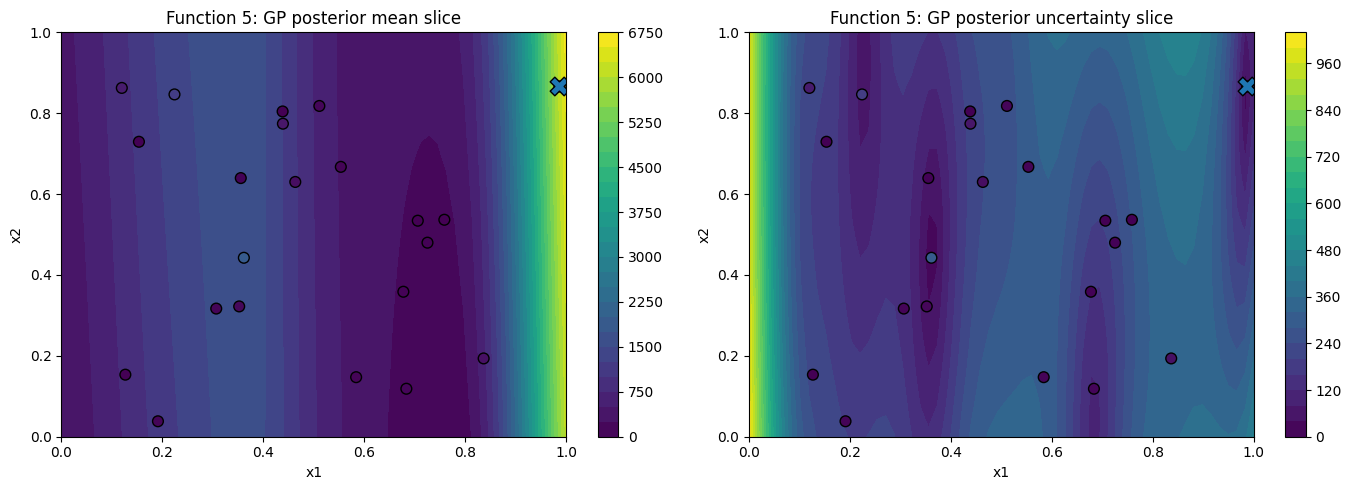

Best X used as slice centre:
[0.98659  0.866087 0.97881  0.997372]
Fitted kernel:
3.22**2 * Matern(length_scale=[0.366, 10, 2.75, 10], nu=2.5) + WhiteKernel(noise_level=2.35e-10)


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


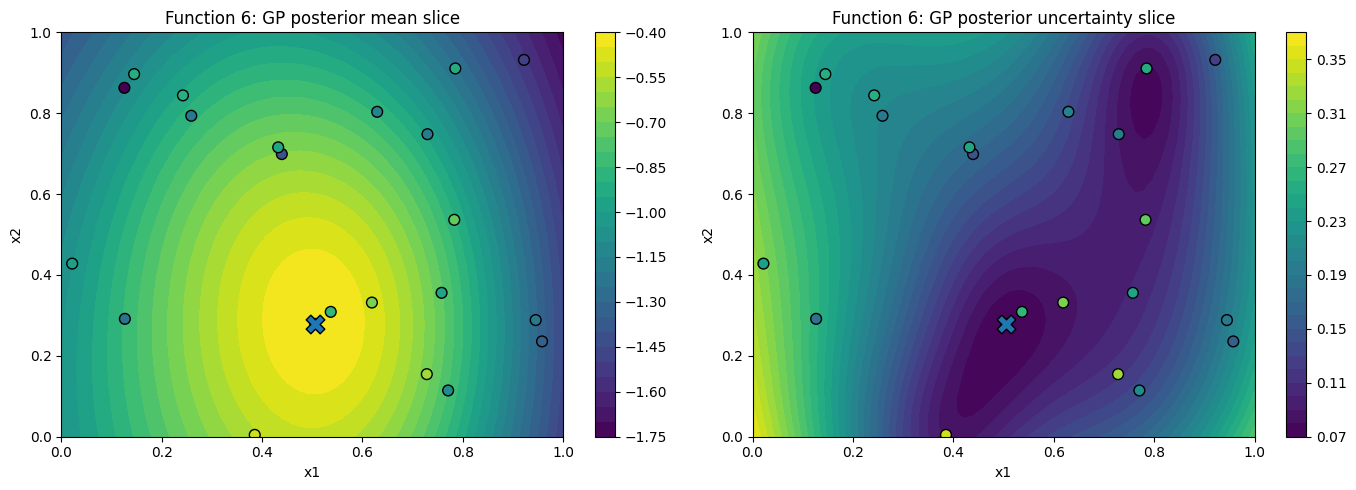

Best X used as slice centre:
[0.505435 0.279076 0.635842 0.932969 0.005307]
Fitted kernel:
1.62**2 * Matern(length_scale=[0.691, 1.2, 1.44, 1.6, 1.39], nu=2.5) + WhiteKernel(noise_level=0.01)


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


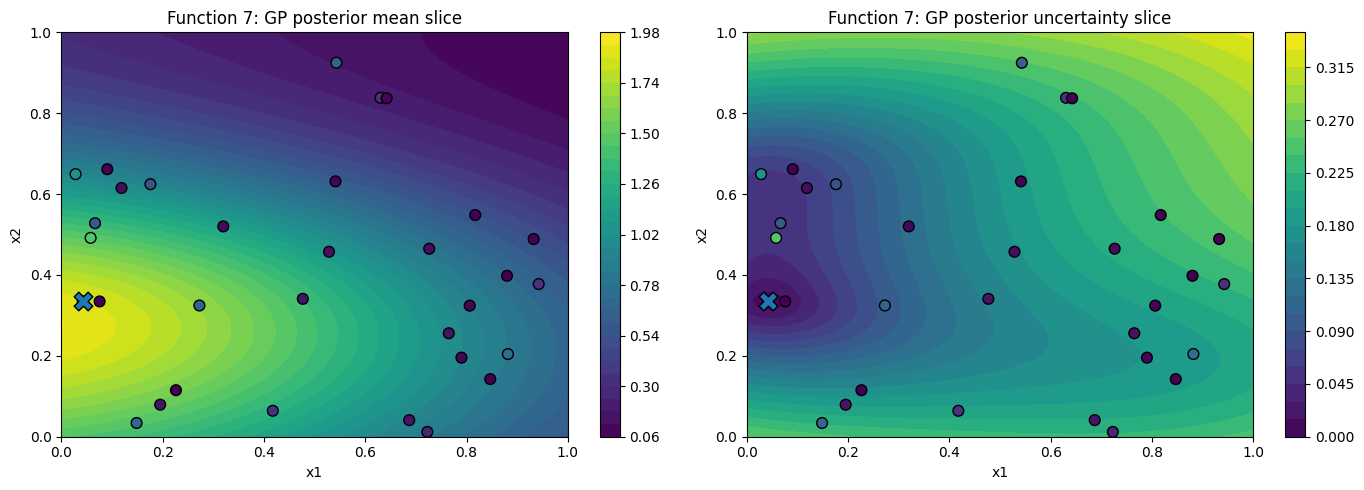

Best X used as slice centre:
[0.042483 0.33487  0.652742 0.13207  0.397409 0.736186]
Fitted kernel:
1.15**2 * Matern(length_scale=[1.13, 0.5, 10, 0.862, 0.398, 0.648], nu=2.5) + WhiteKernel(noise_level=6.42e-10)


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 4 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 7 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


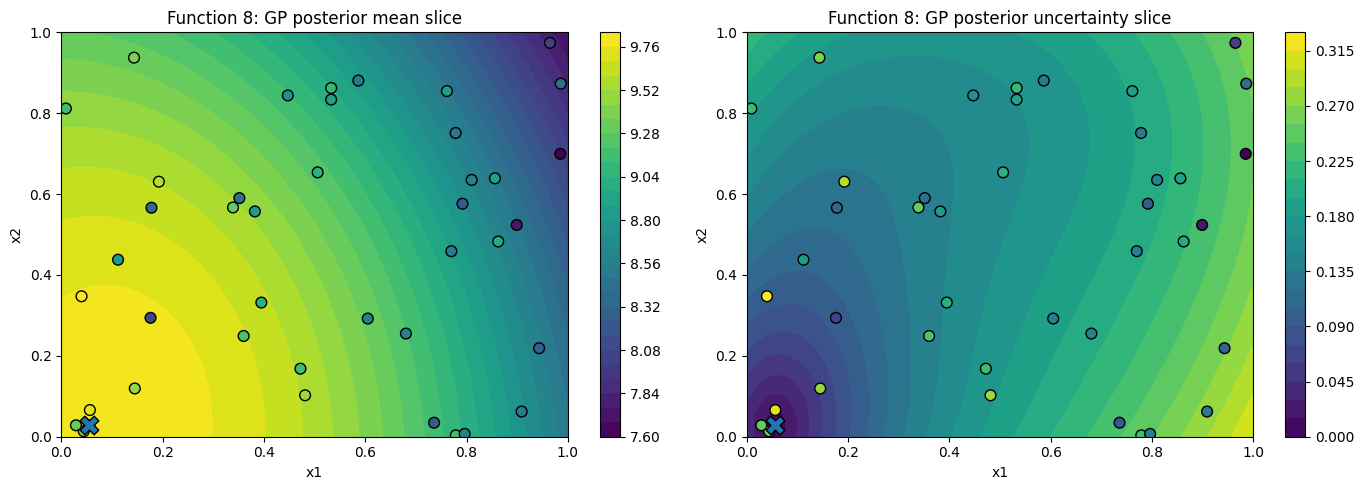

Best X used as slice centre:
[5.54650e-02 2.79980e-02 3.08203e-01 1.99000e-04 9.50318e-01 5.98844e-01
 8.72710e-02 3.01130e-01]
Fitted kernel:
2.45**2 * Matern(length_scale=[3.46, 5.72, 2.65, 8.23, 10, 7.54, 3.61, 10], nu=1.5) + WhiteKernel(noise_level=1e-10)


In [10]:
plot_gp_2d_slice(3, dims=(0, 1), nu=1.5)
plot_gp_2d_slice(4, dims=(0, 1), nu=2.5)
plot_gp_2d_slice(5, dims=(0, 1), nu=2.5)
plot_gp_2d_slice(6, dims=(0, 1), nu=2.5)
plot_gp_2d_slice(7, dims=(0, 1), nu=2.5)
plot_gp_2d_slice(8, dims=(0, 1), nu=1.5)

In [11]:
def expected_improvement(mu, sigma, y_best, xi=0.01):
    sigma = np.maximum(sigma, 1e-12)
    z = (mu - y_best - xi) / sigma
    return (mu - y_best - xi) * norm.cdf(z) + sigma * norm.pdf(z)

def upper_confidence_bound(mu, sigma, beta=1.96):
    return mu + beta * sigma

def make_candidate_grid(d, n_candidates=50000, seed=42):
    rng = np.random.default_rng(seed)
    return rng.uniform(0.0, 0.999999, size=(n_candidates, d))


def propose_candidate(
    i,
    kernel_type='matern',
    acquisition='ei',
    seed=42,
    matern_nu=1.5,
    xi=0.01,
    beta=1.96,
    n_candidates=50000
):
    X, Y = load_updated_function_data(i)
    d = X.shape[1]

    if kernel_type == 'matern':
        kernel = (
            ConstantKernel(1.0, (1e-3, 1e3))
            * Matern(length_scale=[0.3]*d,
                     length_scale_bounds=(1e-2, 1e1),
                     nu=matern_nu)
            + WhiteKernel(noise_level=1e-6,
                          noise_level_bounds=(1e-10, 1e-2))
        )
    elif kernel_type == 'rbf':
        kernel = (
            ConstantKernel(1.0, (1e-3, 1e3))
            * RBF(length_scale=[0.3]*d,
                  length_scale_bounds=(1e-2, 1e1))
            + WhiteKernel(noise_level=1e-6,
                          noise_level_bounds=(1e-10, 1e-2))
        )
    else:
        raise ValueError("kernel_type must be 'matern' or 'rbf'")

    gp = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=seed
    )

    gp.fit(X, Y)

    candidates = make_candidate_grid(d, n_candidates=n_candidates, seed=seed + i)
    mu, sigma = gp.predict(candidates, return_std=True)

    if acquisition == 'ei':
        acq = expected_improvement(mu, sigma, np.max(Y), xi=xi)
    elif acquisition == 'ucb':
        acq = upper_confidence_bound(mu, sigma, beta=beta)
    else:
        raise ValueError("acquisition must be 'ei' or 'ucb'")

    best_idx = np.argmax(acq)

    return {
        'function': i,
        'kernel': kernel_type,
        'matern_nu': matern_nu if kernel_type == 'matern' else np.nan,
        'acquisition': acquisition,
        'xi': xi if acquisition == 'ei' else np.nan,
        'beta': beta if acquisition == 'ucb' else np.nan,
        'current_best_y': np.max(Y),
        'current_best_x': X[np.argmax(Y)],
        'candidate_x': candidates[best_idx],
        'pred_mu': mu[best_idx],
        'pred_sigma': sigma[best_idx],
        'acq_value': acq[best_idx],
        'fitted_kernel': gp.kernel_
    }

In [12]:
grid_results = []

nu_list = [0.5, 1.5, 2.5]
xi_list = [0.0, 0.01, 0.05, 0.10]
beta_list = [0.5, 1.0, 1.96, 3.0, 5.0]

for i in range(1, 9):

    # Matérn + EI
    for nu in nu_list:
        for xi in xi_list:
            grid_results.append(
                propose_candidate(i, 'matern', 'ei',
                                  matern_nu=nu, xi=xi, seed=42)
            )

    # Matérn + UCB
    for nu in nu_list:
        for beta in beta_list:
            grid_results.append(
                propose_candidate(i, 'matern', 'ucb',
                                  matern_nu=nu, beta=beta, seed=42)
            )

    # RBF baseline
    for xi in xi_list:
        grid_results.append(
            propose_candidate(i, 'rbf', 'ei',
                              xi=xi, seed=42)
        )

    for beta in beta_list:
        grid_results.append(
            propose_candidate(i, 'rbf', 'ucb',
                              beta=beta, seed=42)
        )

df_grid = pd.DataFrame(grid_results)

df_grid_view = df_grid[
    ['function','kernel','matern_nu','acquisition','xi','beta',
     'current_best_y','candidate_x','pred_mu','pred_sigma','acq_value']
]

display(df_grid_view.round(6))

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: Converg

,function,kernel,matern_nu,acquisition,xi,beta,current_best_y,candidate_x,pred_mu,pred_sigma,acq_value
0,1,matern,0.5,ei,0.00,NaN,0.000000,"[0.2767983472415877, 0.1132020979436942]",-0.000145,0.000937,0.000306
1,1,matern,0.5,ei,0.01,NaN,0.000000,"[0.9627259858997896, 0.9756331977048537]",-0.000292,0.001013,0.000000
2,1,matern,0.5,ei,0.05,NaN,0.000000,"[0.6522986104016479, 0.043775279863672974]",-0.000218,0.000975,0.000000
3,1,matern,0.5,ei,0.10,NaN,0.000000,"[0.6522986104016479, 0.043775279863672974]",-0.000218,0.000975,0.000000
4,1,matern,1.5,ei,0.00,NaN,0.000000,"[0.1451951508451623, 0.4479822709683254]",-0.000130,0.000941,0.000314
...,...,...,...,...,...,...,...,...,...,...,...
283,8,rbf,NaN,ucb,NaN,0.50,9.808024,"[0.34236960715614245, 0.083488266938511, 0.016...",10.100814,0.153386,10.177506
284,8,rbf,NaN,ucb,NaN,1.00,9.808024,"[0.34236960715614245, 0.083488266938511, 0.016...",10.100814,0.153386,10.254199
285,8,rbf,NaN,ucb,NaN,1.96,9.808024,"[0.34236960715614245, 0.083488266938511, 0.016...",10.100814,0.153386,10.401449
286,8,rbf,NaN,ucb,NaN,3.00,9.808024,"[0.34236960715614245, 0.083488266938511, 0.016...",10.100814,0.153386,10.560970


In [13]:

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)


display(df_grid_view.round(6))

,function,kernel,matern_nu,acquisition,xi,beta,current_best_y,candidate_x,pred_mu,pred_sigma,acq_value
0,1,matern,0.5,ei,0.00,NaN,0.000000,"[0.2767983472415877, 0.1132020979436942]",-0.000145,0.000937,0.000306
1,1,matern,0.5,ei,0.01,NaN,0.000000,"[0.9627259858997896, 0.9756331977048537]",-0.000292,0.001013,0.000000
2,1,matern,0.5,ei,0.05,NaN,0.000000,"[0.6522986104016479, 0.043775279863672974]",-0.000218,0.000975,0.000000
3,1,matern,0.5,ei,0.10,NaN,0.000000,"[0.6522986104016479, 0.043775279863672974]",-0.000218,0.000975,0.000000
4,1,matern,1.5,ei,0.00,NaN,0.000000,"[0.1451951508451623, 0.4479822709683254]",-0.000130,0.000941,0.000314
5,1,matern,1.5,ei,0.01,NaN,0.000000,"[0.9510254823026315, 0.9869175417816834]",-0.000296,0.001033,0.000000
6,1,matern,1.5,ei,0.05,NaN,0.000000,"[0.6522986104016479, 0.043775279863672974]",-0.000178,0.000932,0.000000
7,1,matern,1.5,ei,0.10,NaN,0.000000,"[0.6522986104016479, 0.043775279863672974]",-0.000178,0.000932,0.000000
8,1,matern,2.5,ei,0.00,NaN,0.000000,"[0.1451951508451623, 0.4479822709683254]",-0.000125,0.000935,0.000314
9,1,matern,2.5,ei,0.01,NaN,0.000000,"[0.9934550837054288, 0.9830472170204226]",-0.000297,0.001032,0.000000


In [14]:
from scipy.spatial.distance import pdist

convergence_rows = []

for i in range(1, 9):
    sub = df_grid[df_grid['function'] == i].copy()

    X_candidates = np.vstack(sub['candidate_x'].values)

    pairwise_dist = pdist(X_candidates)

    convergence_rows.append({
        'function': i,
        'n_candidates_tested': len(sub),
        'mean_pairwise_distance': pairwise_dist.mean(),
        'max_pairwise_distance': pairwise_dist.max(),
        'min_pairwise_distance': pairwise_dist.min(),
        'std_pairwise_distance': pairwise_dist.std(),
        'best_pred_mu': sub['pred_mu'].max(),
        'best_acq_value': sub['acq_value'].max()
    })

df_convergence = pd.DataFrame(convergence_rows)
display(df_convergence.round(6))

,function,n_candidates_tested,mean_pairwise_distance,max_pairwise_distance,min_pairwise_distance,std_pairwise_distance,best_pred_mu,best_acq_value
0,1,36,0.526261,1.256887,0.0,0.302725,-0.000029,0.004874
1,2,36,0.260860,1.243759,0.0,0.405326,0.616670,1.355205
2,3,36,0.647756,1.350299,0.0,0.400239,-0.025098,0.368328
3,4,36,0.205235,1.418063,0.0,0.298343,0.434894,13.280978
4,5,36,0.720409,1.366777,0.0,0.470793,6532.505598,11760.459022
5,6,36,0.562888,1.486127,0.0,0.315984,-0.317563,1.340058
6,7,36,0.275879,0.704626,0.0,0.212302,1.986653,3.023687
7,8,36,0.573527,1.494365,0.0,0.401904,10.100814,11.702400


In [15]:
display(
    df_grid[
        df_grid['function']==3
    ][[
        'kernel',
        'matern_nu',
        'acquisition',
        'xi',
        'beta',
        'candidate_x',
        'pred_mu',
        'pred_sigma'
    ]]
)

,kernel,matern_nu,acquisition,xi,beta,candidate_x,pred_mu,pred_sigma
72,matern,0.5,ei,0.00,NaN,"[0.8746424559031729, 0.9825303525190232, 0.3992422294632557]",-0.064905,0.073861
73,matern,0.5,ei,0.01,NaN,"[0.8746424559031729, 0.9825303525190232, 0.3992422294632557]",-0.064905,0.073861
74,matern,0.5,ei,0.05,NaN,"[0.9963714553852904, 0.962559640469348, 0.4006585582992012]",-0.064983,0.073919
75,matern,0.5,ei,0.10,NaN,"[0.9963714553852904, 0.962559640469348, 0.4006585582992012]",-0.064983,0.073919
76,matern,1.5,ei,0.00,NaN,"[0.5819033842984942, 0.0038460595929644967, 0.3100883399554584]",-0.025949,0.064399
77,matern,1.5,ei,0.01,NaN,"[0.5819033842984942, 0.0038460595929644967, 0.3100883399554584]",-0.025949,0.064399
78,matern,1.5,ei,0.05,NaN,"[0.2580979171402977, 0.005651473329757876, 0.3092448678691687]",-0.026286,0.064754
79,matern,1.5,ei,0.10,NaN,"[0.06184922429389605, 0.07689475722409105, 0.3077832622607125]",-0.026833,0.065095
80,matern,2.5,ei,0.00,NaN,"[0.7418571611708729, 0.9926382423594186, 0.3976446661528739]",-0.049832,0.070375
81,matern,2.5,ei,0.01,NaN,"[0.7418571611708729, 0.9926382423594186, 0.3976446661528739]",-0.049832,0.070375


In [47]:
df_grid[
    (df_grid.function==5)
].groupby(
    ['kernel','matern_nu']
)[['pred_mu','pred_sigma']].agg(['max','mean','min'])

pred_mu                             pred_sigma  \
                          max         mean          min          max   
kernel matern_nu                                                       
matern 0.5        5862.008997  5619.492736  4603.171492  1003.181361   
       1.5        6414.672809  6143.698962  5531.965413   964.416259   
       2.5        6532.505598  5932.371866  4702.739518  1411.543901   

                                          
                        mean         min  
kernel matern_nu                          
matern 0.5        606.987623  499.813311  
       1.5        468.665002  176.534568  
       2.5        737.392778  405.458086

In [17]:
for f in range(1,9):

    sub = df_grid[df_grid['function']==f]

    X_candidates = np.vstack(sub['candidate_x'].values)

    pairwise_dist = pdist(X_candidates)

    print(f"\nFUNCTION {f}")
    print("Mean distance:", round(pairwise_dist.mean(),4))
    print("Max distance :", round(pairwise_dist.max(),4))

    print("\nBest predicted mu:")
    print(
        sub.loc[sub['pred_mu'].idxmax(),
                ['kernel','matern_nu','acquisition',
                 'xi','beta','pred_mu','pred_sigma']]
    )


FUNCTION 1
Mean distance: 0.5263
Max distance : 1.2569

Best predicted mu:
kernel              rbf
matern_nu           NaN
acquisition         ucb
xi                  NaN
beta                0.5
pred_mu       -0.000029
pred_sigma     0.000771
Name: 31, dtype: object

FUNCTION 2
Mean distance: 0.2609
Max distance : 1.2438

Best predicted mu:
kernel              rbf
matern_nu           NaN
acquisition         ucb
xi                  NaN
beta                0.5
pred_mu         0.61667
pred_sigma     0.053393
Name: 67, dtype: object

FUNCTION 3
Mean distance: 0.6478
Max distance : 1.3503

Best predicted mu:
kernel           matern
matern_nu           1.5
acquisition         ucb
xi                  NaN
beta                0.5
pred_mu       -0.025098
pred_sigma     0.063024
Name: 89, dtype: object

FUNCTION 4
Mean distance: 0.2052
Max distance : 1.4181

Best predicted mu:
kernel           matern
matern_nu           1.5
acquisition         ucb
xi                  NaN
beta                0.5


In [40]:
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import pdist
import numpy as np
import pandas as pd

DEFAULT_FUNCTIONS = [2, 4, 7]

def get_default_candidate(df_grid, function_id):
    """
    Default = Matérn ν=2.5 + EI ξ=0.01
    """
    sub = df_grid[
        (df_grid["function"] == function_id) &
        (df_grid["kernel"] == "matern") &
        (df_grid["matern_nu"] == 2.5) &
        (df_grid["acquisition"] == "ei") &
        (df_grid["xi"] == 0.01)
    ]

    if len(sub) == 0:
        raise ValueError(f"No default candidate found for function {function_id}")

    row = sub.iloc[0].copy()
    row["selection_method"] = "default_matern_2.5_ei"
    return row


def select_candidate_by_cluster(df_grid, function_id, eps=0.25, min_samples=2):
    sub = df_grid[df_grid["function"] == function_id].copy().reset_index(drop=True)

    Xcand = np.vstack(sub["candidate_x"].values)

    clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(Xcand)
    sub["cluster"] = clustering.labels_

    sub["mu_rank"] = sub["pred_mu"].rank(pct=True)
    sub["acq_rank"] = sub["acq_value"].rank(pct=True)

    sub["model_score"] = 0.6 * sub["mu_rank"] + 0.4 * sub["acq_rank"]

    cluster_summary = (
        sub[sub["cluster"] != -1]
        .groupby("cluster")
        .agg(
            n_models=("cluster", "size"),
            avg_score=("model_score", "mean"),
            max_score=("model_score", "max"),
            avg_mu=("pred_mu", "mean"),
            max_mu=("pred_mu", "max"),
            avg_sigma=("pred_sigma", "mean")
        )
        .reset_index()
    )

    if len(cluster_summary) == 0:
        chosen = sub.sort_values("model_score", ascending=False).iloc[0].copy()
        chosen["selection_method"] = "fallback_best_score_no_cluster"
        return chosen, cluster_summary, sub

    cluster_summary["consensus_score"] = (
        cluster_summary["avg_score"] + 0.03 * cluster_summary["n_models"]
    )

    best_cluster = cluster_summary.sort_values(
        "consensus_score", ascending=False
    ).iloc[0]["cluster"]

    chosen = sub[sub["cluster"] == best_cluster].sort_values(
        "model_score", ascending=False
    ).iloc[0].copy()

    chosen["selection_method"] = "cluster_consensus_score"

    return chosen, cluster_summary, sub


def select_final_candidates(df_grid, default_functions=DEFAULT_FUNCTIONS):
    final_rows = []
    diagnostics = {}

    for f in range(1, 9):

        if f in default_functions:
            chosen = get_default_candidate(df_grid, f)
            final_rows.append(chosen)
            diagnostics[f] = {
                "method": "default",
                "cluster_summary": None,
                "labelled_candidates": None
            }

        else:
            chosen, cluster_summary, labelled = select_candidate_by_cluster(df_grid, f)
            final_rows.append(chosen)
            diagnostics[f] = {
                "method": "cluster",
                "cluster_summary": cluster_summary,
                "labelled_candidates": labelled
            }

    df_final = pd.DataFrame(final_rows)

    return df_final, diagnostics

In [41]:
df_final, diagnostics = select_final_candidates(
    df_grid,
    default_functions=[2, 4, 7]
)

df_final_view = df_final[
    [
        "function",
        "selection_method",
        "kernel",
        "matern_nu",
        "acquisition",
        "xi",
        "beta",
        "candidate_x",
        "pred_mu",
        "pred_sigma",
        "acq_value"
    ]
]

display(df_final_view.round(6))

,function,selection_method,kernel,matern_nu,acquisition,xi,beta,candidate_x,pred_mu,pred_sigma,acq_value
31,1,cluster_consensus_score,rbf,NaN,ucb,NaN,0.5,"[0.9866524415575442, 0.11320473916037911]",-0.000029,0.000771,0.000357
45,2,default_matern_2.5_ei,matern,2.5,ei,0.01,NaN,"[0.7313287432391538, 0.9970589049689048]",0.523119,0.126501,0.015877
4,3,cluster_consensus_score,matern,1.5,ei,0.00,NaN,"[0.5819033842984942, 0.0038460595929644967, 0.3100883399554584]",-0.025949,0.064399,0.030379
117,4,default_matern_2.5_ei,matern,2.5,ei,0.01,NaN,"[0.3661150442949004, 0.43495116262863004, 0.3948320003159032, 0.4196353193151279]",-0.059939,0.505775,0.053966
23,5,cluster_consensus_score,matern,2.5,ucb,NaN,1.0,"[0.9988893024718997, 0.9168418894217755, 0.9837714154489424, 0.18702996220743995]",6532.505598,405.458086,6937.963684
27,6,cluster_consensus_score,rbf,NaN,ei,0.00,NaN,"[0.47179946851927146, 0.37501728156967695, 0.5694591345329197, 0.974896432973069, 0.16869328470321246]",-0.317563,0.101045,0.098042
225,7,default_matern_2.5_ei,matern,2.5,ei,0.01,NaN,"[0.069409027248478, 0.2547765993456625, 0.37433601985885545, 0.062255360090157114, 0.32499229015094666, 0.8573927351460713]",1.905895,0.142942,0.072812
34,8,cluster_consensus_score,rbf,NaN,ucb,NaN,3.0,"[0.34236960715614245, 0.083488266938511, 0.01621220515747554, 0.011447618961267659, 0.9956921721304046, 0.3922073233097729, 0.2069742020408152, 0.3402913339532165]",10.100814,0.153386,10.560970


In [20]:
df_final_view.to_csv('final_selection.csv', index=False)

In [48]:
df_final_view_display = df_final_view.copy()

df_final_view_display["candidate_x"] = (
    df_final_view_display["candidate_x"]
    .apply(lambda x: [round(v, 6) for v in x])
)

display(df_final_view_display.round(6))

,function,selection_method,kernel,matern_nu,acquisition,xi,beta,candidate_x,pred_mu,pred_sigma,acq_value
31,1,cluster_consensus_score,rbf,NaN,ucb,NaN,0.5,"[0.986652, 0.113205]",-0.000029,0.000771,0.000357
45,2,default_matern_2.5_ei,matern,2.5,ei,0.01,NaN,"[0.731329, 0.997059]",0.523119,0.126501,0.015877
4,3,cluster_consensus_score,matern,1.5,ei,0.00,NaN,"[0.581903, 0.003846, 0.310088]",-0.025949,0.064399,0.030379
117,4,default_matern_2.5_ei,matern,2.5,ei,0.01,NaN,"[0.366115, 0.434951, 0.394832, 0.419635]",-0.059939,0.505775,0.053966
23,5,cluster_consensus_score,matern,2.5,ucb,NaN,1.0,"[0.998889, 0.916842, 0.983771, 0.18703]",6532.505598,405.458086,6937.963684
27,6,cluster_consensus_score,rbf,NaN,ei,0.00,NaN,"[0.471799, 0.375017, 0.569459, 0.974896, 0.168693]",-0.317563,0.101045,0.098042
225,7,default_matern_2.5_ei,matern,2.5,ei,0.01,NaN,"[0.069409, 0.254777, 0.374336, 0.062255, 0.324992, 0.857393]",1.905895,0.142942,0.072812
34,8,cluster_consensus_score,rbf,NaN,ucb,NaN,3.0,"[0.34237, 0.083488, 0.016212, 0.011448, 0.995692, 0.392207, 0.206974, 0.340291]",10.100814,0.153386,10.560970


In [49]:
submission_strings = []

for _, row in df_final_view_display.iterrows():
    s = "-".join([f"{x:.6f}" for x in row["candidate_x"]])
    submission_strings.append(s)

for i, s in enumerate(submission_strings, start=1):
    print(f"Function {i}: {s}")

Function 1: 0.986652-0.113205
Function 2: 0.731329-0.997059
Function 3: 0.581903-0.003846-0.310088
Function 4: 0.366115-0.434951-0.394832-0.419635
Function 5: 0.998889-0.916842-0.983771-0.187030
Function 6: 0.471799-0.375017-0.569459-0.974896-0.168693
Function 7: 0.069409-0.254777-0.374336-0.062255-0.324992-0.857393
Function 8: 0.342370-0.083488-0.016212-0.011448-0.995692-0.392207-0.206974-0.340291


In [43]:
def extract_ard(i, nu=1.5):

    X, Y = load_updated_function_data(i)

    d = X.shape[1]

    kernel = (
        ConstantKernel(1.0)
        * Matern(
            length_scale=[0.3]*d,
            length_scale_bounds=(1e-2,1e1),
            nu=nu
        )
        + WhiteKernel(1e-6)
    )

    gp = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=42
    )

    gp.fit(X,Y)

    ls = gp.kernel_.k1.k2.length_scale

    return pd.DataFrame({
        "dimension": range(1,d+1),
        "length_scale": ls
    }).sort_values("length_scale")

In [24]:
extract_ard(1,nu=2.5)

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,dimension,length_scale
1,2,0.030939
0,1,10.000000


In [25]:
for f in range(1,9):
    print(f"\nFUNCTION {f}")
    display(extract_ard(f, nu=2.5))


FUNCTION 1


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,dimension,length_scale
1,2,0.030939
0,1,10.000000



FUNCTION 2


,dimension,length_scale
0,1,0.053585
1,2,4.800085


...

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,dimension,length_scale
4,5,0.398008
1,2,0.500438
5,6,0.648089
3,4,0.861697
0,1,1.131070
2,3,10.000000



FUNCTION 8


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 4 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 7 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,dimension,length_scale
2,3,2.378283
6,7,2.974877
0,1,2.989692
1,2,4.648168
5,6,4.895036
3,4,5.567865
4,5,10.000000
7,8,10.000000


In [26]:
for nu in [0.5, 1.5, 2.5]:
    print(f"\nnu={nu}")

    ard = extract_ard(1, nu=nu)

    display(ard)


nu=0.5


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,dimension,length_scale
1,2,0.027004
0,1,10.000000



nu=1.5


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,dimension,length_scale
1,2,0.031703
0,1,10.000000



nu=2.5


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,dimension,length_scale
1,2,0.030939
0,1,10.000000


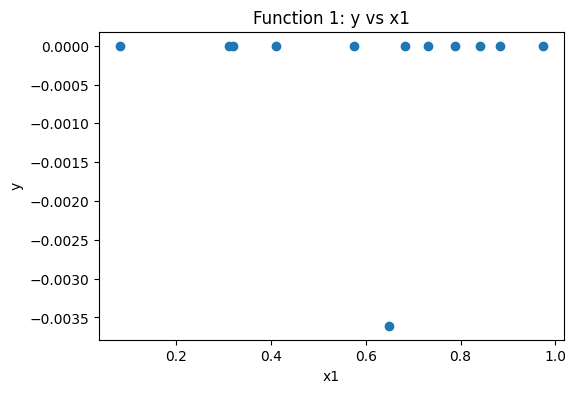

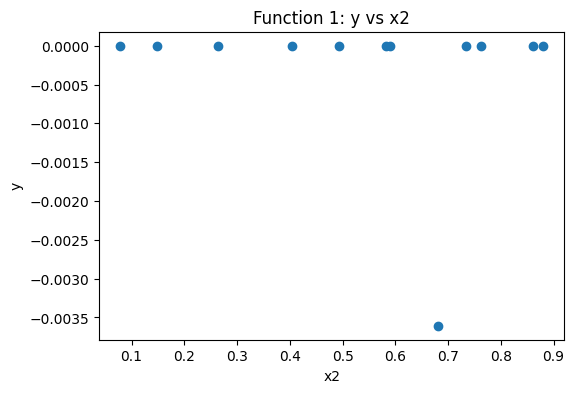

In [27]:
X,Y = load_updated_function_data(1)

plt.figure(figsize=(6,4))
plt.scatter(X[:,0],Y)
plt.xlabel("x1")
plt.ylabel("y")
plt.title("Function 1: y vs x1")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(X[:,1],Y)
plt.xlabel("x2")
plt.ylabel("y")
plt.title("Function 1: y vs x2")
plt.show()

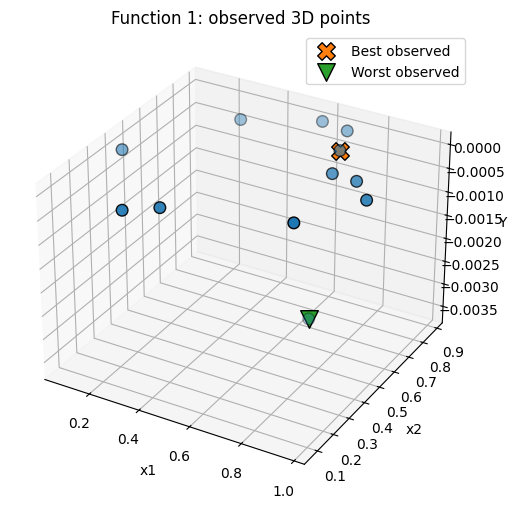

In [29]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

def plot_3d_observed_function(i):
    X, Y = load_updated_function_data(i)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(
        X[:, 0],
        X[:, 1],
        Y,
        s=70,
        edgecolor='black'
    )

    best_idx = np.argmax(Y)
    worst_idx = np.argmin(Y)

    ax.scatter(
        X[best_idx, 0],
        X[best_idx, 1],
        Y[best_idx],
        s=160,
        marker='X',
        edgecolor='black',
        label='Best observed'
    )

    ax.scatter(
        X[worst_idx, 0],
        X[worst_idx, 1],
        Y[worst_idx],
        s=160,
        marker='v',
        edgecolor='black',
        label='Worst observed'
    )

    ax.set_title(f"Function {i}: observed 3D points")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_zlabel("Y")

    ax.legend()
    plt.show()

plot_3d_observed_function(1)

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Fitted kernel:
1.04**2 * Matern(length_scale=[10, 0.0309], nu=2.5) + WhiteKernel(noise_level=7.11e-08)


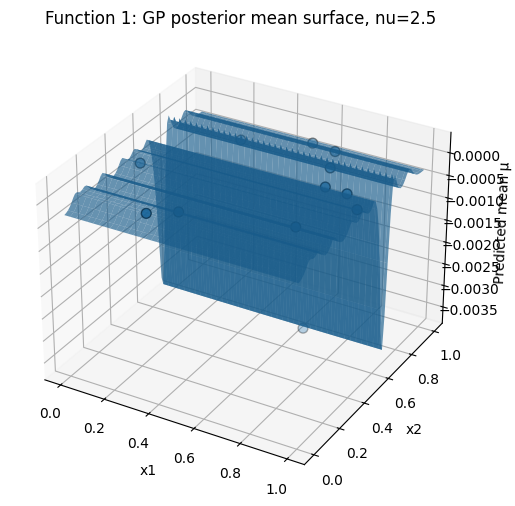

In [30]:
def plot_gp_3d_surface_function1(nu=2.5, grid_size=80):
    X, Y = load_updated_function_data(1)
    d = X.shape[1]

    kernel = (
        ConstantKernel(1.0, (1e-3, 1e3))
        * Matern(
            length_scale=[0.3]*d,
            length_scale_bounds=(1e-2, 1e1),
            nu=nu
        )
        + WhiteKernel(
            noise_level=1e-6,
            noise_level_bounds=(1e-10, 1e-2)
        )
    )

    gp = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=42
    )

    gp.fit(X, Y)

    x1_grid = np.linspace(0, 1, grid_size)
    x2_grid = np.linspace(0, 1, grid_size)

    X1, X2 = np.meshgrid(x1_grid, x2_grid)

    X_grid = np.column_stack([
        X1.ravel(),
        X2.ravel()
    ])

    mu, sigma = gp.predict(X_grid, return_std=True)

    MU = mu.reshape(grid_size, grid_size)
    SIGMA = sigma.reshape(grid_size, grid_size)

    fig = plt.figure(figsize=(9, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(
        X1,
        X2,
        MU,
        alpha=0.65,
        linewidth=0,
        antialiased=True
    )

    ax.scatter(
        X[:, 0],
        X[:, 1],
        Y,
        s=50,
        edgecolor='black'
    )

    ax.set_title(f"Function 1: GP posterior mean surface, nu={nu}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_zlabel("Predicted mean μ")

    print("Fitted kernel:")
    print(gp.kernel_)

    plt.show()

plot_gp_3d_surface_function1(nu=2.5)